In [78]:
import pandas as pd
import re
import scipy, os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [79]:
basedir = "C:\\Users\\c2070256\\OneDrive - Cardiff University\\Desktop\\Cardiff Uni\\courses\\Dissertation\\data"

# Readind and cleaning the datasets

In [80]:
#reading and loading dataset 1:audio feautures of songs
def load_csv_1(basedir):
  return pd.read_csv(os.path.join(basedir, 'tracks.csv'))

In [81]:
df1 = load_csv_1(basedir)
df1.head()

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126903,0,['Uli'],['45tIt06XoI0Iio4LBEVpls'],1922-02-22,0.645,0.4450,0,-13.338,1,0.4510,0.674,0.7440,0.151,0.127,104.851,3
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.695,0.2630,0,-22.136,1,0.9570,0.797,0.0000,0.148,0.655,102.009,1
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181640,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.434,0.1770,1,-21.180,1,0.0512,0.994,0.0218,0.212,0.457,130.418,5
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176907,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.321,0.0946,7,-27.961,1,0.0504,0.995,0.9180,0.104,0.397,169.980,3
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163080,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],1922,0.402,0.1580,3,-16.900,0,0.0390,0.989,0.1300,0.311,0.196,103.220,4


In [82]:
# size of the dataset
df1.shape

(586672, 20)

In [83]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 586672 entries, 0 to 586671
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                586672 non-null  object 
 1   name              586601 non-null  object 
 2   popularity        586672 non-null  int64  
 3   duration_ms       586672 non-null  int64  
 4   explicit          586672 non-null  int64  
 5   artists           586672 non-null  object 
 6   id_artists        586672 non-null  object 
 7   release_date      586672 non-null  object 
 8   danceability      586672 non-null  float64
 9   energy            586672 non-null  float64
 10  key               586672 non-null  int64  
 11  loudness          586672 non-null  float64
 12  mode              586672 non-null  int64  
 13  speechiness       586672 non-null  float64
 14  acousticness      586672 non-null  float64
 15  instrumentalness  586672 non-null  float64
 16  liveness          58

In [84]:
# cleaning the dataset of NaN values
for column in df1.columns[:]:
    print(df1[column].isna().sum())

0
71
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


In [85]:
nan_value = float("NaN")
df1.replace("", nan_value, inplace=True)
df1.dropna(subset = ["name"], inplace=True)

In [86]:
# size of cleaned dataset 
df1.shape

(586601, 20)

In [87]:
df1["release_date"] = df1["release_date"].astype('str')

In [88]:
df1.head()

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126903,0,['Uli'],['45tIt06XoI0Iio4LBEVpls'],1922-02-22,0.645,0.4450,0,-13.338,1,0.4510,0.674,0.7440,0.151,0.127,104.851,3
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.695,0.2630,0,-22.136,1,0.9570,0.797,0.0000,0.148,0.655,102.009,1
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181640,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.434,0.1770,1,-21.180,1,0.0512,0.994,0.0218,0.212,0.457,130.418,5
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176907,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.321,0.0946,7,-27.961,1,0.0504,0.995,0.9180,0.104,0.397,169.980,3
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163080,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],1922,0.402,0.1580,3,-16.900,0,0.0390,0.989,0.1300,0.311,0.196,103.220,4


In [89]:
# add new column in the dataset with the year of the song's release as an integer, not the full date as a string
df1['release_date_initial'] = df1['release_date'].str[:4].astype(int)

In [90]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 586601 entries, 0 to 586671
Data columns (total 21 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    586601 non-null  object 
 1   name                  586601 non-null  object 
 2   popularity            586601 non-null  int64  
 3   duration_ms           586601 non-null  int64  
 4   explicit              586601 non-null  int64  
 5   artists               586601 non-null  object 
 6   id_artists            586601 non-null  object 
 7   release_date          586601 non-null  object 
 8   danceability          586601 non-null  float64
 9   energy                586601 non-null  float64
 10  key                   586601 non-null  int64  
 11  loudness              586601 non-null  float64
 12  mode                  586601 non-null  int64  
 13  speechiness           586601 non-null  float64
 14  acousticness          586601 non-null  float64
 15  

In [91]:
df1.head()

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,release_date_initial
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126903,0,['Uli'],['45tIt06XoI0Iio4LBEVpls'],1922-02-22,0.645,0.4450,...,-13.338,1,0.4510,0.674,0.7440,0.151,0.127,104.851,3,1922
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.695,0.2630,...,-22.136,1,0.9570,0.797,0.0000,0.148,0.655,102.009,1,1922
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181640,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.434,0.1770,...,-21.180,1,0.0512,0.994,0.0218,0.212,0.457,130.418,5,1922
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176907,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.321,0.0946,...,-27.961,1,0.0504,0.995,0.9180,0.104,0.397,169.980,3,1922
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163080,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],1922,0.402,0.1580,...,-16.900,0,0.0390,0.989,0.1300,0.311,0.196,103.220,4,1922


In [92]:
#reading and loading dataset 2: spotify top 200 charts (2017-2021)
def load_csv_2(basedir):
  return pd.read_csv(os.path.join(basedir, 'Spotify Top 200 Global (2017-2021).csv'))

In [93]:
df2 = load_csv_2(basedir)
df2.head()

,Rank,Track,Artist,Streams,Link,Week,Album_Name,Duration_MS,Explicit,Track_Number_on_Album,Artist_Followers,Artist_Genres
0,1,Starboy,The Weeknd,25734078,https://open.spotify.com/track/5aAx2yezTd8zXrk...,2017-01-06,Starboy,230453,True,1,31348348,"['canadian contemporary r&b', 'canadian pop', ..."
1,2,Closer,The Chainsmokers,23519705,https://open.spotify.com/track/7BKLCZ1jbUBVqRi...,2017-01-06,Closer,244960,False,1,17742887,"['dance pop', 'edm', 'electropop', 'pop', 'pop..."
2,3,Rockabye (feat. Sean Paul & Anne-Marie),Clean Bandit,21216399,https://open.spotify.com/track/5knuzwU65gJK7IF...,2017-01-06,Rockabye (feat. Sean Paul & Anne-Marie),251088,False,1,4296325,"['dance pop', 'edm', 'pop', 'pop dance', 'post..."
3,4,Let Me Love You,DJ Snake,19852704,https://open.spotify.com/track/4pdPtRcBmOSQDlJ...,2017-01-06,Encore,205946,False,13,7312319,"['dance pop', 'edm', 'electronic trap', 'pop',..."
4,5,I Don’t Wanna Live Forever (Fifty Shades Darke...,ZAYN,18316326,https://open.spotify.com/track/3NdDpSvN911VPGi...,2017-01-06,I Don’t Wanna Live Forever (Fifty Shades Darker),245200,False,1,15423979,"['dance pop', 'pop', 'post-teen pop', 'uk pop']"


In [94]:
df2.shape

(44200, 12)

In [95]:
# clearing the dataset from NaN values
for column in df2.columns[:]:
    print(df2[column].isna().sum())

0
5
5
0
0
0
5
0
0
0
0
0


In [96]:
nan_value = float("NaN")
df2.replace("", nan_value, inplace=True)
df2.dropna(subset = ["Track"], inplace=True)

In [97]:
# size of cleared dataset
df2.shape

(44195, 12)

# Merging name- Track columns

In [98]:
# removing duplicates
df_test_1 = df1.drop_duplicates(subset = ["name"])

In [99]:
df_test_2 = df2.drop_duplicates(subset = ["Track"])

In [100]:
# size of datasets after removing duplicates
df_test_1.shape, df1.shape

((446474, 21), (586601, 21))

In [101]:
df_test_1.head()

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,release_date_initial
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126903,0,['Uli'],['45tIt06XoI0Iio4LBEVpls'],1922-02-22,0.645,0.4450,...,-13.338,1,0.4510,0.674,0.7440,0.151,0.127,104.851,3,1922
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.695,0.2630,...,-22.136,1,0.9570,0.797,0.0000,0.148,0.655,102.009,1,1922
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181640,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.434,0.1770,...,-21.180,1,0.0512,0.994,0.0218,0.212,0.457,130.418,5,1922
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176907,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.321,0.0946,...,-27.961,1,0.0504,0.995,0.9180,0.104,0.397,169.980,3,1922
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163080,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],1922,0.402,0.1580,...,-16.900,0,0.0390,0.989,0.1300,0.311,0.196,103.220,4,1922


In [102]:
# finding common indexes in both datasets
common,idx_df1,idx_df2 = np.intersect1d(
        df_test_1.name, 
        df_test_2.Track,
        return_indices=True
)

In [103]:
print(idx_df1,idx_df2)

[208484  64398  97809 ...  78898 340889 421827] [2227  212 3116 ...  764 3304  333]


In [104]:
len(common)

2714

In [105]:
common[:100]

array(['!', "'Till I Collapse", '+Linda', '...Ready For It?',
       '00:00 (Zero O’Clock)',
       '1, 2, 3 (feat. Jason Derulo & De La Ghetto)', '1-800-273-8255',
       '10 Freaky Girls (with 21 Savage)',
       '10,000 Hours (with Justin Bieber)',
       '11 Minutes (with Halsey feat. Travis Barker)', '11 PM', '110',
       '120', '13 Beaches', '134340', '1400 / 999 Freestyle', '1950',
       '1985 - Intro to “The Fall Off”', '1999', '2 Much', '200 km/h',
       '2002', '2012', '21', "223's (feat. 9lokknine)",
       '24 (feat. Lil Baby)', '24K Magic', '25/8',
       '2U (feat. Justin Bieber)', '3 A.M.', '3 Nights', '34+35',
       '34+35 Remix (feat. Doja Cat, Megan Thee Stallion) - Remix', '365',
       '4 AM', '44 BullDog', '44 More', '4422', '4th Dimension',
       '5 Songs in einer Nacht', '5% TINT', '500 PS', '6 Kiss', '66',
       '7 Minutes', '7 Summers', '7 Years', '7 rings', '8', '8 Letters',
       '865', '90-60-111', '90MIN', "91's", '911',
       '911 / Mr. Lonely (fea

In [106]:
df_hit=df_test_1.iloc[idx_df1]

In [107]:
# creating dataset only with common rows
df_hit

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,release_date_initial
264860,1A05ibu1DXGIt0F62NG7xU,!,40,163957,0,"['Samey', 'Gleb']","['0p0V7LW8i3S22J7xErqdmt', '6P55YsIOHmgooCXGQX...",2019-09-01,0.762,0.6610,...,-8.855,1,0.5580,0.1020,0.000000,0.6920,0.6640,84.718,4,2019
75436,4xkOaSrkexMciUUogZKVTS,'Till I Collapse,85,297787,1,"['Eminem', 'Nate Dogg']","['7dGJo4pcD2V6oG8kP0tJRR', '1Oa0bMld0A3u5OTYfM...",2002-05-26,0.548,0.8470,...,-3.237,1,0.1860,0.0622,0.000000,0.0816,0.1000,171.447,4,2002
118479,5cBrOhKDyiJF9bPGUHKkG0,+Linda,76,161748,0,['Dalex'],['0KPX4Ucy9dk82uj4GpKesn'],2020-04-20,0.660,0.5030,...,-5.501,1,0.3400,0.1310,0.000000,0.1300,0.3960,175.896,4,2020
90412,2yLa0QULdQr0qAIvVwN6B5,...Ready For It?,73,208187,0,['Taylor Swift'],['06HL4z0CvFAxyc27GXpf02'],2017-11-10,0.613,0.7640,...,-6.509,1,0.1360,0.0527,0.000000,0.1970,0.4170,160.015,4,2017
211649,4AlihYDqxXshKhvh5tnMfP,00:00 (Zero O’Clock),74,250296,0,['BTS'],['3Nrfpe0tUJi4K4DXYWgMUX'],2020-02-21,0.566,0.5480,...,-6.456,1,0.0579,0.0802,0.000000,0.1100,0.1960,157.999,4,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92832,45bE4HXI0AwGZXfZtMp8JR,you broke me first,91,169266,0,['Tate McRae'],['45dkTj5sMRSjrmBSBeiHym'],2020-04-17,0.667,0.3730,...,-9.389,1,0.0500,0.7850,0.000000,0.0906,0.0823,124.148,4,2020
92018,3XF5xLJHOQQRbWya6hBp7d,you should see me in a crown,80,180953,0,['Billie Eilish'],['6qqNVTkY8uBg9cP3Jd7DAH'],2019-03-29,0.678,0.5330,...,-10.485,1,0.1860,0.4620,0.219000,0.1390,0.3230,150.455,4,2019
92647,0mlAOSILGRys2IbvyOT5VJ,Échame La Culpa,74,173800,0,"['Luis Fonsi', 'Demi Lovato']","['4V8Sr092TqfHkfAA5fXXqG', '6S2OmqARrzebs0tKUE...",2019-02-01,0.733,0.8970,...,-3.652,1,0.0389,0.0391,0.000000,0.1170,0.6490,96.006,4,2019
444508,7dW84mWkdWE5a6lFWxJCBG,‘tis the damn season,74,229840,0,['Taylor Swift'],['06HL4z0CvFAxyc27GXpf02'],2020-12-11,0.575,0.4340,...,-8.193,1,0.0312,0.7350,0.000066,0.1050,0.3480,145.916,4,2020


In [108]:
# adding 'hit' column as target value
df_hit.insert(21, 'hit', 1)

In [109]:
df_hit

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,release_date_initial,hit
264860,1A05ibu1DXGIt0F62NG7xU,!,40,163957,0,"['Samey', 'Gleb']","['0p0V7LW8i3S22J7xErqdmt', '6P55YsIOHmgooCXGQX...",2019-09-01,0.762,0.6610,...,1,0.5580,0.1020,0.000000,0.6920,0.6640,84.718,4,2019,1
75436,4xkOaSrkexMciUUogZKVTS,'Till I Collapse,85,297787,1,"['Eminem', 'Nate Dogg']","['7dGJo4pcD2V6oG8kP0tJRR', '1Oa0bMld0A3u5OTYfM...",2002-05-26,0.548,0.8470,...,1,0.1860,0.0622,0.000000,0.0816,0.1000,171.447,4,2002,1
118479,5cBrOhKDyiJF9bPGUHKkG0,+Linda,76,161748,0,['Dalex'],['0KPX4Ucy9dk82uj4GpKesn'],2020-04-20,0.660,0.5030,...,1,0.3400,0.1310,0.000000,0.1300,0.3960,175.896,4,2020,1
90412,2yLa0QULdQr0qAIvVwN6B5,...Ready For It?,73,208187,0,['Taylor Swift'],['06HL4z0CvFAxyc27GXpf02'],2017-11-10,0.613,0.7640,...,1,0.1360,0.0527,0.000000,0.1970,0.4170,160.015,4,2017,1
211649,4AlihYDqxXshKhvh5tnMfP,00:00 (Zero O’Clock),74,250296,0,['BTS'],['3Nrfpe0tUJi4K4DXYWgMUX'],2020-02-21,0.566,0.5480,...,1,0.0579,0.0802,0.000000,0.1100,0.1960,157.999,4,2020,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92832,45bE4HXI0AwGZXfZtMp8JR,you broke me first,91,169266,0,['Tate McRae'],['45dkTj5sMRSjrmBSBeiHym'],2020-04-17,0.667,0.3730,...,1,0.0500,0.7850,0.000000,0.0906,0.0823,124.148,4,2020,1
92018,3XF5xLJHOQQRbWya6hBp7d,you should see me in a crown,80,180953,0,['Billie Eilish'],['6qqNVTkY8uBg9cP3Jd7DAH'],2019-03-29,0.678,0.5330,...,1,0.1860,0.4620,0.219000,0.1390,0.3230,150.455,4,2019,1
92647,0mlAOSILGRys2IbvyOT5VJ,Échame La Culpa,74,173800,0,"['Luis Fonsi', 'Demi Lovato']","['4V8Sr092TqfHkfAA5fXXqG', '6S2OmqARrzebs0tKUE...",2019-02-01,0.733,0.8970,...,1,0.0389,0.0391,0.000000,0.1170,0.6490,96.006,4,2019,1
444508,7dW84mWkdWE5a6lFWxJCBG,‘tis the damn season,74,229840,0,['Taylor Swift'],['06HL4z0CvFAxyc27GXpf02'],2020-12-11,0.575,0.4340,...,1,0.0312,0.7350,0.000066,0.1050,0.3480,145.916,4,2020,1


In [110]:
# when were hit songs released
df_hit['release_date_initial'].unique()

array([2019, 2002, 2020, 2017, 2018, 1983, 1982, 2021, 2016, 2011, 1965,
       2013, 1988, 2015, 2014, 1948, 1991, 1973, 2006, 1986, 1981, 1984,
       1994, 1997, 1992, 1924, 1963, 1931, 1968, 2010, 1934, 2012, 1980,
       2003, 1998, 1993, 1964, 1987, 1957, 1937, 1971, 1945, 1956, 1990,
       1960, 1967, 1951, 2008, 2007, 1975, 1961, 1996, 2000, 1969, 1942,
       1922, 1930, 1970, 1925, 2004, 1955, 1977, 2005, 2009, 1959, 1978,
       1943, 1974, 1953, 1958, 1989, 1979, 1999, 2001, 1947, 1932, 1976,
       1939, 1985, 1954, 1929, 1949, 1962, 1946, 1952, 1941, 1995, 1972,
       1928, 1950, 1966, 1927, 1933])

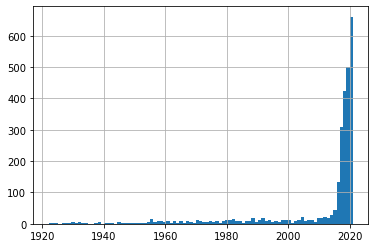

In [111]:
# distribution of hit song release years
hist = df_hit['release_date_initial'].hist(bins=93)

In [112]:
# creating dataframe of uncommon songs between datasets
df_uncommon = df_test_1.merge(df_hit, how = 'outer' ,indicator=True).loc[lambda x : x['_merge']=='left_only']

df_uncommon

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,release_date_initial,hit,_merge
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126903,0,['Uli'],['45tIt06XoI0Iio4LBEVpls'],1922-02-22,0.645,0.4450,...,0.4510,0.674,0.744000,0.1510,0.1270,104.851,3,1922,NaN,left_only
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.695,0.2630,...,0.9570,0.797,0.000000,0.1480,0.6550,102.009,1,1922,NaN,left_only
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181640,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.434,0.1770,...,0.0512,0.994,0.021800,0.2120,0.4570,130.418,5,1922,NaN,left_only
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176907,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.321,0.0946,...,0.0504,0.995,0.918000,0.1040,0.3970,169.980,3,1922,NaN,left_only
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163080,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],1922,0.402,0.1580,...,0.0390,0.989,0.130000,0.3110,0.1960,103.220,4,1922,NaN,left_only
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
446469,0SjsIzJkZfDU7wlcdklEFR,John Brown's Song,66,185250,0,['Gregory Oberle'],['4MxqhahGRT4BPz1PilXGeu'],2020-03-20,0.562,0.0331,...,0.1030,0.996,0.961000,0.1110,0.3860,63.696,3,2020,NaN,left_only
446470,5rgu12WBIHQtvej2MdHSH0,云与海,50,258267,0,['阿YueYue'],['1QLBXKM5GCpyQQSVMNZqrZ'],2020-09-26,0.560,0.5180,...,0.0292,0.785,0.000000,0.0648,0.2110,131.896,4,2020,NaN,left_only
446471,0NuWgxEp51CutD2pJoF4OM,blind,72,153293,0,['ROLE MODEL'],['1dy5WNgIKQU6ezkpZs4y8z'],2020-10-21,0.765,0.6630,...,0.0652,0.141,0.000297,0.0924,0.6860,150.091,4,2020,NaN,left_only
446472,27Y1N4Q4U3EfDU5Ubw8ws2,What They'll Say About Us,70,187601,0,['FINNEAS'],['37M5pPGs6V1fchFJSgCguX'],2020-09-02,0.535,0.3140,...,0.0408,0.895,0.000150,0.0874,0.0663,145.095,4,2020,NaN,left_only


In [113]:
# keep only songs released after 2017
# df_uncommon=df_uncommon[df_uncommon.release_date_initial > 2017]

In [114]:
df_uncommon

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,release_date_initial,hit,_merge
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126903,0,['Uli'],['45tIt06XoI0Iio4LBEVpls'],1922-02-22,0.645,0.4450,...,0.4510,0.674,0.744000,0.1510,0.1270,104.851,3,1922,NaN,left_only
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.695,0.2630,...,0.9570,0.797,0.000000,0.1480,0.6550,102.009,1,1922,NaN,left_only
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181640,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.434,0.1770,...,0.0512,0.994,0.021800,0.2120,0.4570,130.418,5,1922,NaN,left_only
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176907,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.321,0.0946,...,0.0504,0.995,0.918000,0.1040,0.3970,169.980,3,1922,NaN,left_only
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163080,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],1922,0.402,0.1580,...,0.0390,0.989,0.130000,0.3110,0.1960,103.220,4,1922,NaN,left_only
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
446469,0SjsIzJkZfDU7wlcdklEFR,John Brown's Song,66,185250,0,['Gregory Oberle'],['4MxqhahGRT4BPz1PilXGeu'],2020-03-20,0.562,0.0331,...,0.1030,0.996,0.961000,0.1110,0.3860,63.696,3,2020,NaN,left_only
446470,5rgu12WBIHQtvej2MdHSH0,云与海,50,258267,0,['阿YueYue'],['1QLBXKM5GCpyQQSVMNZqrZ'],2020-09-26,0.560,0.5180,...,0.0292,0.785,0.000000,0.0648,0.2110,131.896,4,2020,NaN,left_only
446471,0NuWgxEp51CutD2pJoF4OM,blind,72,153293,0,['ROLE MODEL'],['1dy5WNgIKQU6ezkpZs4y8z'],2020-10-21,0.765,0.6630,...,0.0652,0.141,0.000297,0.0924,0.6860,150.091,4,2020,NaN,left_only
446472,27Y1N4Q4U3EfDU5Ubw8ws2,What They'll Say About Us,70,187601,0,['FINNEAS'],['37M5pPGs6V1fchFJSgCguX'],2020-09-02,0.535,0.3140,...,0.0408,0.895,0.000150,0.0874,0.0663,145.095,4,2020,NaN,left_only


In [115]:
df_uncommon['release_date_initial'].unique()

array([1922, 1923, 1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931, 1932,
       1933, 1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941, 1942, 1943,
       1944, 1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952, 1953, 1954,
       1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965,
       1966, 1968, 2008, 2020, 2018, 1997, 2006, 1991, 2012, 2015, 2011,
       1992, 2007, 2021, 2013, 2014, 2017, 1967, 1969, 1970, 1971, 1972,
       1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983,
       1984, 1985, 1986, 1987, 1988, 1989, 1990, 1993, 1994, 1995, 1996,
       1998, 1999, 2019, 2000, 2009, 2010, 2016, 2004, 2003, 2005, 2001,
       2002, 1900])

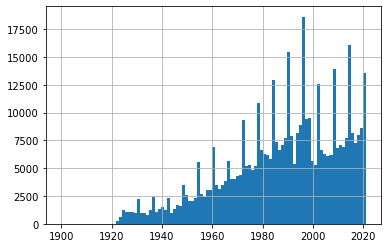

In [116]:
# distribution of hit song release years
hist = df_uncommon['release_date_initial'].hist(bins=101)

In [117]:
# select 2714 non hit songs to create a balanced final dataset
df_non_hit=df_uncommon.sample(n = 2714)

In [118]:
df_non_hit

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,release_date_initial,hit,_merge
344387,1feOaXwpdAtKphBT1uXxoU,Setengah Lima,39,255493,0,['Sore'],['175PwHedjMlt2ujXwfX64A'],2008-04-24,0.211,0.488,...,0.0279,0.0542,0.000300,0.1510,0.382,97.957,3,2008,NaN,left_only
170904,3ZR1sXeLOwxDuNshV8BKPu,Tantina,33,473627,0,['Soukous Stars'],['7wcl2LtA0w6O3KveN0Nico'],1993-01-01,0.698,0.757,...,0.0328,0.5530,0.000104,0.0817,0.835,133.479,4,1993,NaN,left_only
28424,1RDf4ztdqoovN89CWgZ5cL,Rockin' At The Philharmonic,18,202613,0,['Chuck Berry'],['293zczrfYafIItmnmM3coR'],1958-03-01,0.548,0.688,...,0.0376,0.4970,0.946000,0.1880,0.892,104.978,4,1958,NaN,left_only
346531,5JR8e4FGxj7lgrEmvRqRCl,Josefien,14,189057,0,['Cocktail Trio'],['7ufPy0TGzzLPsQdXG4EVbN'],1981-01-15,0.795,0.604,...,0.0744,0.7050,0.000000,0.2420,0.958,113.883,4,1981,NaN,left_only
173346,2PIbYqiHOaQac9fyxQ8tKv,Four Day Creep,0,255947,0,['Brownie McGhee'],['3qXzj7WzBV3kwy1yEV1RcC'],1951-01-01,0.756,0.155,...,0.0493,0.9220,0.017200,0.0999,0.603,108.636,4,1951,NaN,left_only
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
409676,3LleLIUWzzfYSZOpAiuFFd,Pojdme se napit,26,263693,0,"['Robert Krestan', 'Druha Trava']","['0CdtwFKaEDLi5QAkda8Rd1', '1BhaLTpqKqNysxEWp4...",2013-10-21,0.671,0.532,...,0.0281,0.5910,0.002420,0.1340,0.622,117.131,4,2013,NaN,left_only
159067,2idqsRubfcyORaRRqRcK55,Hasta Dónde,39,193280,0,['Kany Garcia'],['69UypehHabb68utzfjAVlV'],2009-09-17,0.583,0.520,...,0.0296,0.0240,0.000000,0.1160,0.385,141.816,4,2009,NaN,left_only
136486,3qkoTJyZFzpsYPE2n3uh0p,Ei kai Hectorillakaan ole helppoa,14,171000,0,['Freud Marx Engels & Jung'],['3yke87s3oocT5my2YLulfe'],1989-01-01,0.605,0.691,...,0.0257,0.1100,0.000000,0.1390,0.890,93.016,4,1989,NaN,left_only
178277,4Ndf5S7esfUDucEYJQgtbD,הבא בתור הוא סוס,29,268000,0,['Nosei Hamigbaat'],['1yCsJSY67pNiJXfD1Jmwtq'],1991-01-01,0.525,0.762,...,0.0306,0.0202,0.001570,0.0598,0.609,140.824,4,1991,NaN,left_only


In [119]:
# adding 'hit' column as target value
df_non_hit['hit']= 0

In [120]:
df_non_hit=df_non_hit.drop(['_merge'], axis=1)

In [121]:
df_non_hit

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,release_date_initial,hit
344387,1feOaXwpdAtKphBT1uXxoU,Setengah Lima,39,255493,0,['Sore'],['175PwHedjMlt2ujXwfX64A'],2008-04-24,0.211,0.488,...,0,0.0279,0.0542,0.000300,0.1510,0.382,97.957,3,2008,0
170904,3ZR1sXeLOwxDuNshV8BKPu,Tantina,33,473627,0,['Soukous Stars'],['7wcl2LtA0w6O3KveN0Nico'],1993-01-01,0.698,0.757,...,1,0.0328,0.5530,0.000104,0.0817,0.835,133.479,4,1993,0
28424,1RDf4ztdqoovN89CWgZ5cL,Rockin' At The Philharmonic,18,202613,0,['Chuck Berry'],['293zczrfYafIItmnmM3coR'],1958-03-01,0.548,0.688,...,0,0.0376,0.4970,0.946000,0.1880,0.892,104.978,4,1958,0
346531,5JR8e4FGxj7lgrEmvRqRCl,Josefien,14,189057,0,['Cocktail Trio'],['7ufPy0TGzzLPsQdXG4EVbN'],1981-01-15,0.795,0.604,...,1,0.0744,0.7050,0.000000,0.2420,0.958,113.883,4,1981,0
173346,2PIbYqiHOaQac9fyxQ8tKv,Four Day Creep,0,255947,0,['Brownie McGhee'],['3qXzj7WzBV3kwy1yEV1RcC'],1951-01-01,0.756,0.155,...,1,0.0493,0.9220,0.017200,0.0999,0.603,108.636,4,1951,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
409676,3LleLIUWzzfYSZOpAiuFFd,Pojdme se napit,26,263693,0,"['Robert Krestan', 'Druha Trava']","['0CdtwFKaEDLi5QAkda8Rd1', '1BhaLTpqKqNysxEWp4...",2013-10-21,0.671,0.532,...,1,0.0281,0.5910,0.002420,0.1340,0.622,117.131,4,2013,0
159067,2idqsRubfcyORaRRqRcK55,Hasta Dónde,39,193280,0,['Kany Garcia'],['69UypehHabb68utzfjAVlV'],2009-09-17,0.583,0.520,...,1,0.0296,0.0240,0.000000,0.1160,0.385,141.816,4,2009,0
136486,3qkoTJyZFzpsYPE2n3uh0p,Ei kai Hectorillakaan ole helppoa,14,171000,0,['Freud Marx Engels & Jung'],['3yke87s3oocT5my2YLulfe'],1989-01-01,0.605,0.691,...,1,0.0257,0.1100,0.000000,0.1390,0.890,93.016,4,1989,0
178277,4Ndf5S7esfUDucEYJQgtbD,הבא בתור הוא סוס,29,268000,0,['Nosei Hamigbaat'],['1yCsJSY67pNiJXfD1Jmwtq'],1991-01-01,0.525,0.762,...,1,0.0306,0.0202,0.001570,0.0598,0.609,140.824,4,1991,0


In [122]:
df_non_hit['release_date_initial'].unique()

array([2008, 1993, 1958, 1981, 1951, 1996, 2004, 2015, 1955, 2002, 1980,
       1982, 1994, 1990, 1967, 1999, 1943, 1945, 1953, 1960, 2016, 2011,
       2013, 1956, 2019, 1972, 1984, 2014, 1998, 2020, 1939, 2007, 2018,
       1959, 1962, 1997, 1973, 1988, 1949, 1995, 1983, 1991, 2009, 1934,
       2005, 1968, 1963, 2017, 1986, 1985, 2001, 2000, 1942, 1974, 1947,
       1964, 1975, 1976, 1971, 1966, 1992, 1978, 1952, 1936, 1969, 1965,
       2010, 1937, 1987, 1924, 2006, 2003, 1946, 1930, 1938, 1979, 1957,
       1950, 1935, 2012, 1989, 1977, 2021, 1970, 1961, 1931, 1948, 1954,
       1940, 1927, 1925, 1933, 1932, 1944, 1929, 1941, 1928, 1922, 1926,
       1923])

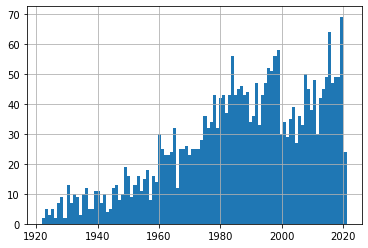

In [123]:
# distribution of hit song release years
hist = df_non_hit['release_date_initial'].hist(bins=100)

In [124]:
# creating the final dataset of hit and non hit songs
df_final=pd.concat([df_hit, df_non_hit])

In [125]:
df_final

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,release_date_initial,hit
264860,1A05ibu1DXGIt0F62NG7xU,!,40,163957,0,"['Samey', 'Gleb']","['0p0V7LW8i3S22J7xErqdmt', '6P55YsIOHmgooCXGQX...",2019-09-01,0.762,0.661,...,1,0.5580,0.1020,0.00000,0.6920,0.664,84.718,4,2019,1
75436,4xkOaSrkexMciUUogZKVTS,'Till I Collapse,85,297787,1,"['Eminem', 'Nate Dogg']","['7dGJo4pcD2V6oG8kP0tJRR', '1Oa0bMld0A3u5OTYfM...",2002-05-26,0.548,0.847,...,1,0.1860,0.0622,0.00000,0.0816,0.100,171.447,4,2002,1
118479,5cBrOhKDyiJF9bPGUHKkG0,+Linda,76,161748,0,['Dalex'],['0KPX4Ucy9dk82uj4GpKesn'],2020-04-20,0.660,0.503,...,1,0.3400,0.1310,0.00000,0.1300,0.396,175.896,4,2020,1
90412,2yLa0QULdQr0qAIvVwN6B5,...Ready For It?,73,208187,0,['Taylor Swift'],['06HL4z0CvFAxyc27GXpf02'],2017-11-10,0.613,0.764,...,1,0.1360,0.0527,0.00000,0.1970,0.417,160.015,4,2017,1
211649,4AlihYDqxXshKhvh5tnMfP,00:00 (Zero O’Clock),74,250296,0,['BTS'],['3Nrfpe0tUJi4K4DXYWgMUX'],2020-02-21,0.566,0.548,...,1,0.0579,0.0802,0.00000,0.1100,0.196,157.999,4,2020,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
409676,3LleLIUWzzfYSZOpAiuFFd,Pojdme se napit,26,263693,0,"['Robert Krestan', 'Druha Trava']","['0CdtwFKaEDLi5QAkda8Rd1', '1BhaLTpqKqNysxEWp4...",2013-10-21,0.671,0.532,...,1,0.0281,0.5910,0.00242,0.1340,0.622,117.131,4,2013,0
159067,2idqsRubfcyORaRRqRcK55,Hasta Dónde,39,193280,0,['Kany Garcia'],['69UypehHabb68utzfjAVlV'],2009-09-17,0.583,0.520,...,1,0.0296,0.0240,0.00000,0.1160,0.385,141.816,4,2009,0
136486,3qkoTJyZFzpsYPE2n3uh0p,Ei kai Hectorillakaan ole helppoa,14,171000,0,['Freud Marx Engels & Jung'],['3yke87s3oocT5my2YLulfe'],1989-01-01,0.605,0.691,...,1,0.0257,0.1100,0.00000,0.1390,0.890,93.016,4,1989,0
178277,4Ndf5S7esfUDucEYJQgtbD,הבא בתור הוא סוס,29,268000,0,['Nosei Hamigbaat'],['1yCsJSY67pNiJXfD1Jmwtq'],1991-01-01,0.525,0.762,...,1,0.0306,0.0202,0.00157,0.0598,0.609,140.824,4,1991,0


In [126]:
# resetting the indexes
# df_final.sample(frac=1)
df_final = df_final.sample(frac=1).reset_index(drop=True)

In [127]:
df_final

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,release_date_initial,hit
0,0HTyWmZkeC8nlGsPhmYt3I,Solo quiero bailar,49,184333,0,['Zenttric'],['20jf9i6PaxxocCOIuJivGJ'],2009-04-10,0.659,0.891,...,0,0.0259,0.128000,0.000000,0.0999,0.583,138.989,4,2009,0
1,7gqIqyeCaV2xNtfZWxEphD,Cuídate,65,169533,0,['La Oreja de Van Gogh'],['4U7lXyKdSf1JbM1aXvsodC'],2000-09-07,0.662,0.798,...,1,0.0335,0.306000,0.000000,0.1740,0.542,141.007,4,2000,0
2,3rb5K4Cw0GsLsgjcSYAP9K,リライト,53,225493,0,['ASIAN KUNG-FU GENERATION'],['0MK8l3nURwwQIjafvXoJJt'],2004-10-20,0.499,0.935,...,1,0.0434,0.000172,0.170000,0.0487,0.557,89.495,4,2004,0
3,6JV2JOEocMgcZxYSZelKcc,CAN'T STOP THE FEELING! (Original Song from Dr...,78,236002,0,['Justin Timberlake'],['31TPClRtHm23RisEBtV3X7'],2016-05-06,0.667,0.830,...,1,0.0749,0.012300,0.000000,0.1910,0.701,113.030,4,2016,1
4,04cd1MHVq1D8v1nuTZoCdv,Puntos Suspensivos,70,186316,0,['Piso 21'],['4bw2Am3p9ji3mYsXNXtQcd'],2018-05-11,0.823,0.731,...,0,0.1030,0.175000,0.000000,0.1310,0.952,152.024,4,2018,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5423,3TXPBs44mEXDQdxL60XqIN,Balkenbri-j,23,231640,0,['Boh Foi Toch'],['0feReJjYdpx3MpWnY2H4J3'],1992-06-27,0.647,0.523,...,1,0.0874,0.031300,0.000007,0.3230,0.899,117.245,4,1992,0
5424,2TH65lNHgvLxCKXM3apjxI,Callaita,82,250534,1,"['Bad Bunny', 'Tainy']","['4q3ewBCX7sLwd24euuV69X', '0GM7qgcRCORpGnfcN2...",2019-05-31,0.610,0.624,...,1,0.3090,0.600000,0.000002,0.2430,0.244,176.169,4,2019,1
5425,4O3RwH1TFG1EjPezLIYehI,Life's A Mess II (with Clever & Post Malone),79,206734,1,"['Juice WRLD', 'Clever', 'Post Malone']","['4MCBfE4596Uoi2O4DtmEMz', '5yy76ufVriyvidNSvX...",2021-03-05,0.530,0.370,...,1,0.0279,0.806000,0.000000,0.1120,0.701,140.061,4,2021,1
5426,5BJBwAUC0G6qf2tWw4LUV7,Knowin’ There Is a Friend,8,197942,0,['White Angels'],['4IrQKQCGw3dFBVENk9FfUr'],1987-10-01,0.555,0.286,...,1,0.0451,0.341000,0.000804,0.1420,0.552,121.418,4,1987,0


In [129]:
df_final.to_csv('C:/Users/c2070256/OneDrive - Cardiff University/Desktop/Cardiff Uni/courses/Dissertation/data/df_final.csv')

# Data exploration

In [130]:
df_final.describe()

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,release_date_initial,hit
count,5428.000000,5.428000e+03,5428.000000,5428.000000,5428.000000,5428.000000,5428.000000,5428.000000,5428.000000,5428.000000,5428.000000,5428.000000,5428.000000,5428.000000,5428.000000,5428.000000,5428.000000
mean,45.883198,2.189622e+05,0.196942,0.613280,0.581083,5.254606,-8.724491,0.625645,0.114869,0.357946,0.076932,0.196647,0.530774,119.702762,3.914333,1998.795873,0.500000
std,27.439465,9.211068e+04,0.397725,0.168172,0.226652,3.563790,4.727375,0.484001,0.163016,0.327668,0.225804,0.163309,0.244977,29.743164,0.404773,24.080036,0.500046
min,0.000000,1.462900e+04,0.000000,0.000000,0.000458,0.000000,-40.072000,0.000000,0.000000,0.000001,0.000000,0.018900,0.000000,0.000000,0.000000,1922.000000,0.000000
25%,22.000000,1.746000e+05,0.000000,0.507000,0.427000,2.000000,-10.953250,0.000000,0.036700,0.062600,0.000000,0.097475,0.339000,96.246750,4.000000,1983.000000,0.000000
50%,47.000000,2.068735e+05,0.000000,0.630000,0.609000,5.000000,-7.483000,1.000000,0.053900,0.246000,0.000004,0.130000,0.532500,118.617500,4.000000,2010.000000,0.500000
75%,72.000000,2.465435e+05,0.000000,0.736250,0.755000,8.000000,-5.371000,1.000000,0.110000,0.637000,0.001050,0.246000,0.725000,139.117500,4.000000,2018.000000,1.000000
max,100.000000,2.506423e+06,1.000000,0.980000,0.999000,11.000000,1.933000,1.000000,0.965000,0.996000,0.995000,0.991000,0.991000,211.968000,5.000000,2021.000000,1.000000


In [131]:
df_final.skew()

popularity             -0.183070
duration_ms             5.865561
explicit                1.524522
danceability           -0.466654
energy                 -0.419279
key                    -0.001591
loudness               -1.489958
mode                   -0.519384
speechiness             3.512274
acousticness            0.611362
instrumentalness        2.998357
liveness                2.228687
valence                -0.041169
tempo                   0.365547
time_signature         -3.783096
release_date_initial   -1.091290
hit                     0.000000
dtype: float64

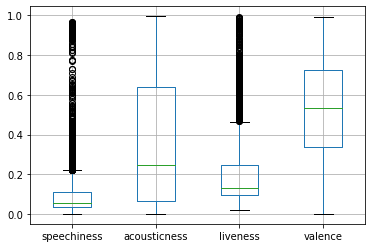

In [132]:
df_final[['speechiness','acousticness', 'liveness', 'valence']].boxplot()

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x0000021CCA2C9FA0>,
      dtype=object)

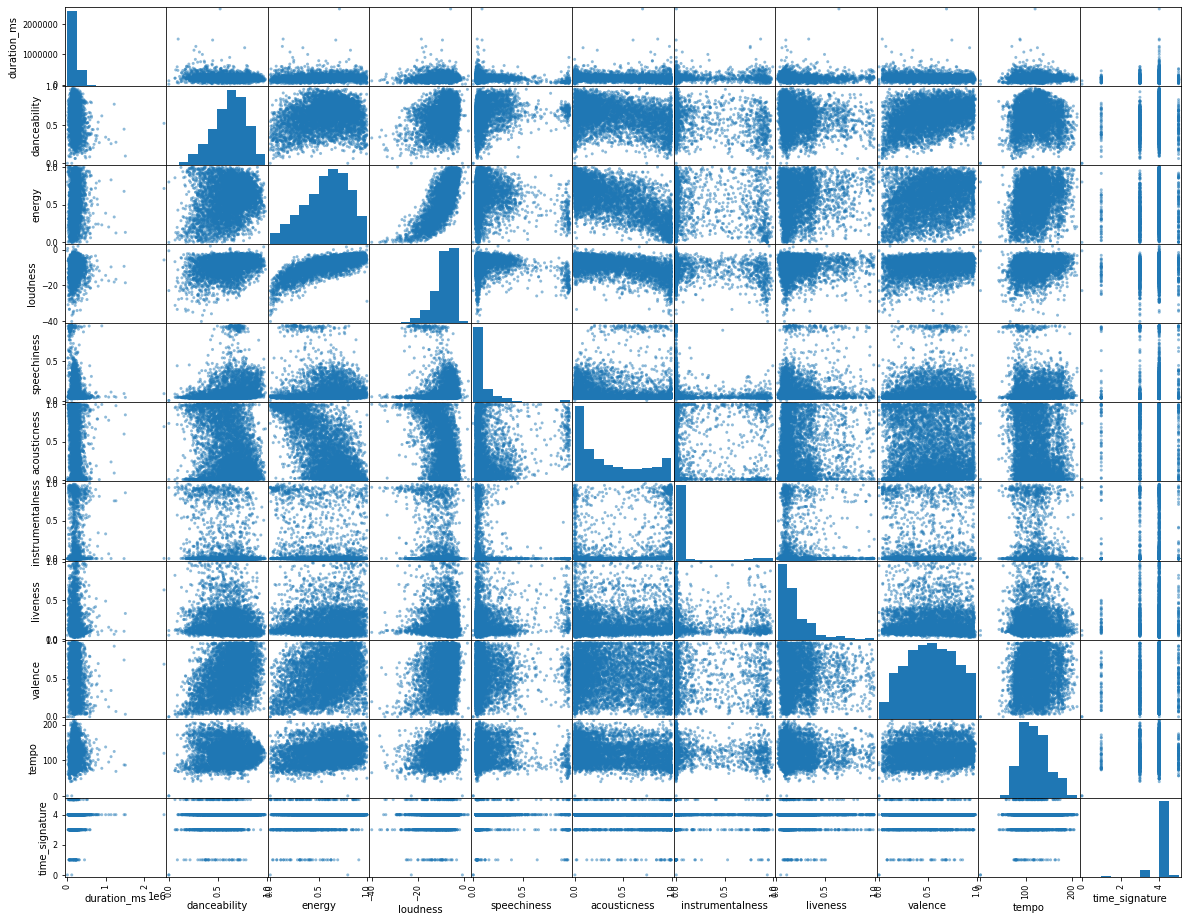

In [133]:
from pandas.plotting import scatter_matrix
scatter_matrix(df_final[['duration_ms','danceability','energy','loudness','speechiness','acousticness','instrumentalness','liveness','valence','tempo','time_signature']], figsize=(20, 16))


[Text(0.5, 0, 'popularity'),
 Text(1.5, 0, 'duration_ms'),
 Text(2.5, 0, 'danceability'),
 Text(3.5, 0, 'energy'),
 Text(4.5, 0, 'loudness'),
 Text(5.5, 0, 'speechiness'),
 Text(6.5, 0, 'acousticness'),
 Text(7.5, 0, 'instrumentalness'),
 Text(8.5, 0, 'liveness'),
 Text(9.5, 0, 'valence'),
 Text(10.5, 0, 'tempo'),
 Text(11.5, 0, 'time_signature')]

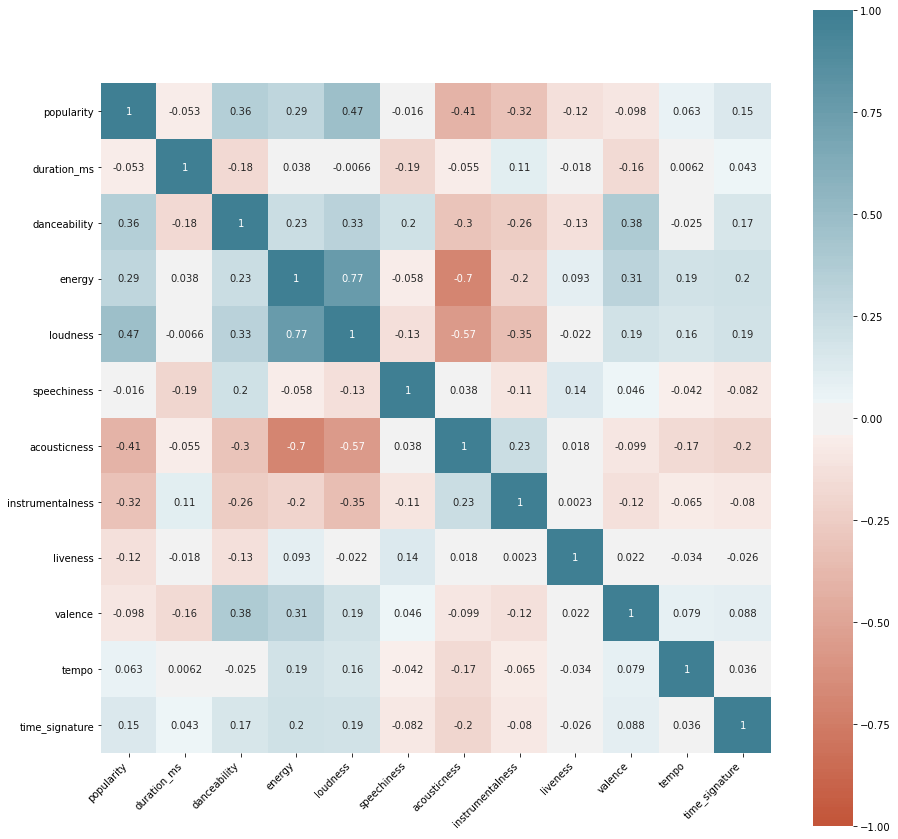

In [134]:
corr = df_final.drop(['explicit', 'key','mode','release_date_initial','hit'], axis=1).corr()
fig, ax = plt.subplots(figsize=(15,15))
ax = sns.heatmap(
    corr, 
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True,
    annot = True
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
)

In [135]:
df_final=df_final.drop(df_final.columns[[0,1,2,5,6,7,20]],axis=1)

In [136]:
df_final

,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,hit
0,184333,0,0.659,0.891,7,-3.143,0,0.0259,0.128000,0.000000,0.0999,0.583,138.989,4,0
1,169533,0,0.662,0.798,8,-4.627,1,0.0335,0.306000,0.000000,0.1740,0.542,141.007,4,0
2,225493,0,0.499,0.935,4,-4.293,1,0.0434,0.000172,0.170000,0.0487,0.557,89.495,4,0
3,236002,0,0.667,0.830,0,-5.715,1,0.0749,0.012300,0.000000,0.1910,0.701,113.030,4,1
4,186316,0,0.823,0.731,11,-3.399,0,0.1030,0.175000,0.000000,0.1310,0.952,152.024,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5423,231640,0,0.647,0.523,2,-14.643,1,0.0874,0.031300,0.000007,0.3230,0.899,117.245,4,0
5424,250534,1,0.610,0.624,2,-4.773,1,0.3090,0.600000,0.000002,0.2430,0.244,176.169,4,1
5425,206734,1,0.530,0.370,6,-9.989,1,0.0279,0.806000,0.000000,0.1120,0.701,140.061,4,1
5426,197942,0,0.555,0.286,0,-20.369,1,0.0451,0.341000,0.000804,0.1420,0.552,121.418,4,0


In [137]:
# selecting the audio features 
#dataframe:
df_x=df_final.iloc[:,[0,1,2,3,4,5,6,7,8,9,10,11,12,13]]
df_y=df_final.iloc[:,[14]]
#list:
# df_x=df_final.iloc[:, :-1].values
# df_y=df_final.iloc[:, -1].values

In [138]:
# splitting the dataframe to training and testing dataframes
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df_x, df_y, test_size=0.25, random_state=0)
X_test

,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
2708,171427,0,0.363,0.316,5,-9.545,1,0.0360,0.847000,0.000000,0.4280,0.356,124.161,3
1625,417800,0,0.286,0.907,7,-9.670,1,0.0374,0.000277,0.202000,0.0837,0.746,156.395,4
3158,158493,0,0.506,0.416,6,-10.364,1,0.0776,0.807000,0.000000,0.3360,0.492,124.678,4
2382,266000,0,0.535,0.566,10,-7.336,1,0.0280,0.412000,0.000000,0.1310,0.310,132.901,4
142,201813,1,0.762,0.562,6,-6.090,1,0.1960,0.333000,0.000520,0.4260,0.851,90.022,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5250,151267,0,0.502,0.172,2,-14.486,1,0.0318,0.531000,0.000000,0.4820,0.527,72.386,4
3326,222333,0,0.706,0.633,9,-9.042,0,0.0289,0.675000,0.002890,0.0846,0.627,130.219,4
3303,103968,0,0.810,0.298,2,-14.944,1,0.2480,0.138000,0.725000,0.0857,0.843,120.890,4
1708,100933,0,0.268,0.967,7,-3.559,1,0.1070,0.046300,0.000000,0.1620,0.769,204.826,4


#  Feature Scaling

In [139]:
from imblearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler, RobustScaler, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_transformer

# transformer for categorical features
categorical_features = ['key', 'mode','explicit']
categorical_transformer = Pipeline(
    [
        ('onehot', OneHotEncoder(handle_unknown = 'ignore'))
    ]
)

# transformer for numerical features
numeric_features = ['duration_ms', 'danceability', 'energy', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']
numeric_transformer = Pipeline(
    [
        ('scaler', PowerTransformer())
    ]
)

# transformer for negative numerical features
negative_numeric_features = ['loudness']
negative_numeric_transformer = Pipeline(
    [
        ('scaler', StandardScaler())
    ]
)


# combine them in a single ColumnTransformer
preprocessor = ColumnTransformer(
    [
        ('categoricals', categorical_transformer, categorical_features),
        ('numericals', numeric_transformer, numeric_features),
        ('negative_numericals', negative_numeric_transformer, negative_numeric_features)
    ],
    remainder = 'drop'
)


# Logistic Regression, KNN, XGBoost, SVM classifiers 

In [140]:
# Training the model on the Training set
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
import sklearn.metrics as metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
classifiers=[KNeighborsClassifier(),LogisticRegression(random_state=42),XGBClassifier(random_state=42),SVC(random_state=42)]
for i in classifiers:
    model=i
    steps = [('preprocessing', preprocessor),('model', model)]
    pipeline = Pipeline(steps=steps)

    #fit pipeline
    pipe = pipeline.fit(X_train,y_train)
    print(model)

    #results
    y_pred = pipe.predict(X_test)
    print('Metrics:')
    print(metrics.classification_report(y_test, y_pred))
    accuracy = accuracy_score(y_test,y_pred)
    print('Accuracy: %f' % accuracy)
    matrix = confusion_matrix(y_test, y_pred)
    print('Confusion matrix : \n',matrix)

C:\Users\c2070256\Anaconda3\lib\site-packages\imblearn\pipeline.py:281: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  self._final_estimator.fit(Xt, yt, **fit_params)


KNeighborsClassifier()
Metrics:
              precision    recall  f1-score   support

           0       0.72      0.72      0.72       667
           1       0.73      0.73      0.73       690

    accuracy                           0.72      1357
   macro avg       0.72      0.72      0.72      1357
weighted avg       0.72      0.72      0.72      1357

Accuracy: 0.723655
Confusion matrix : 
 [[477 190]
 [185 505]]
LogisticRegression(random_state=42)
Metrics:
              precision    recall  f1-score   support

           0       0.74      0.79      0.76       667
           1       0.78      0.73      0.75       690

    accuracy                           0.76      1357
   macro avg       0.76      0.76      0.76      1357
weighted avg       0.76      0.76      0.76      1357

Accuracy: 0.756080
Confusion matrix : 
 [[524 143]
 [188 502]]


C:\Users\c2070256\Anaconda3\lib\site-packages\sklearn\utils\validation.py:73: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(**kwargs)
C:\Users\c2070256\Anaconda3\lib\site-packages\xgboost\sklearn.py:888: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
C:\Users\c2070256\Anaconda3\lib\site-packages\sklearn\utils\validation.py:73: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(**kwargs)


[21:20:27] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.3.0/src/learner.cc:1061: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, gamma=0, gpu_id=-1,
              importance_type='gain', interaction_constraints='',
              learning_rate=0.300000012, max_delta_step=0, max_depth=6,
              min_child_weight=1, missing=nan, monotone_constraints='()',
              n_estimators=100, n_jobs=8, num_parallel_tree=1, random_state=42,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
              tree_method='exact', validate_parameters=1, verbosity=None)
Metrics:
              precision    recall  f1-score   support

           0       0.74      0.82      0.78

C:\Users\c2070256\Anaconda3\lib\site-packages\sklearn\utils\validation.py:73: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(**kwargs)


SVC(random_state=42)
Metrics:
              precision    recall  f1-score   support

           0       0.73      0.85      0.79       667
           1       0.83      0.70      0.76       690

    accuracy                           0.77      1357
   macro avg       0.78      0.78      0.77      1357
weighted avg       0.78      0.77      0.77      1357

Accuracy: 0.774503
Confusion matrix : 
 [[566 101]
 [205 485]]


# Evaluation- Optimization

In [141]:
from sklearn.model_selection import RepeatedStratifiedKFold,RandomizedSearchCV
model = LogisticRegression(random_state=42)
# over=SMOTE(sampling_strategy=0.3)
steps = [('preprocessing', preprocessor),('model', model)]
pipeline = Pipeline(steps=steps)

# define search space
C = np.logspace(1, 4, 20)
penalty = ['l1', 'l2']
solver = ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
param_grid = {'model__C' : C ,'model__penalty': penalty, 'model__solver':solver} 

# define evaluation
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3,random_state=42)

# define search
search = RandomizedSearchCV(pipeline1, param_grid1,scoring='accuracy', n_jobs=-1, cv=cv)

# execute search
result = search.fit(X_train,y_train)

# confusion matrix
matrix = confusion_matrix(y_test, y_pred)

# summarize result
print('Best Accuracy: %s' % result1.best_score_)
print('Best Hyperparameters: %s' % result1.best_params_)
print('Confusion matrix : \n',matrix)

Best Accuracy: 0.7663954417328651
Best Hyperparameters: {'model__solver': 'newton-cg', 'model__penalty': 'l2', 'model__C': 1128.8378916846884}
Confusion matrix : 
 [[566 101]
 [205 485]]


C:\Users\c2070256\Anaconda3\lib\site-packages\sklearn\utils\validation.py:73: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(**kwargs)


In [142]:
# define classification model
model =  XGBClassifier(random_state=42)
steps = [('preprocessing', preprocessor),('model', model)]
pipeline = Pipeline(steps=steps)

# define search space
max_depth=list(range(12))
min_child_weight=list(range(12))
learning_rate = [0.0001, 0.001, 0.01, 0.1, 0.25, 0.5,0.75]
gamma=[i/10.0 for i in range(0,5)]
n_estimators = list(range(0,500,50))
subsample= [0.1,0.25,0.5,0.75,1]

param_grid={'model__max_depth':max_depth,
             'model__learning_rate':learning_rate,
             'model__gamma':gamma,
             'model__min_child_weight':min_child_weight,
             'model__n_estimators':n_estimators,
             'model__subsample':subsample}

# define evaluation
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3,random_state=42)

# define search
search = RandomizedSearchCV(pipeline, param_grid, scoring='accuracy', n_jobs=-1, cv=cv)

# execute search
result = search.fit(X_train, y_train)

# confusion matrix
matrix = confusion_matrix(y_test, y_pred)

# summarize result
print('Best Accuracy: %s' % result.best_score_)
print('Best Hyperparameters: %s' % result.best_params_)
print('Confusion matrix : \n',matrix)

C:\Users\c2070256\Anaconda3\lib\site-packages\xgboost\sklearn.py:888: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
C:\Users\c2070256\Anaconda3\lib\site-packages\sklearn\utils\validation.py:73: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(**kwargs)


[21:21:23] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.3.0/src/learner.cc:1061: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
Best Accuracy: 0.7873532204820549
Best Hyperparameters: {'model__subsample': 0.5, 'model__n_estimators': 150, 'model__min_child_weight': 8, 'model__max_depth': 3, 'model__learning_rate': 0.1, 'model__gamma': 0.2}
Confusion matrix : 
 [[566 101]
 [205 485]]


In [143]:
# define classification model
model =  KNeighborsClassifier()
steps = [('preprocessing', preprocessor),('model', model)]
pipeline = Pipeline(steps=steps)

# define search space
leaf_size = list(range(1,50))
n_neighbors = list(range(1,30))
p=[1,2]
algorithm=['auto', 'ball_tree', 'kd_tree', 'brute']

param_grid={'model__leaf_size':leaf_size,
             'model__n_neighbors':n_neighbors,
             'model__p':p,
             'model__algorithm':algorithm}

# define evaluation
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3,random_state=42)

# define search
search = RandomizedSearchCV(pipeline, param_grid, scoring='accuracy', n_jobs=-1, cv=cv)

# execute search
result = search.fit(X_train, y_train)

# confusion matrix
matrix = confusion_matrix(y_test, y_pred)

# summarize result
print('Best Accuracy: %s' % result.best_score_)
print('Best Hyperparameters: %s' % result.best_params_)
print('Confusion matrix : \n',matrix)

Best Accuracy: 0.760742929209187
Best Hyperparameters: {'model__p': 1, 'model__n_neighbors': 12, 'model__leaf_size': 23, 'model__algorithm': 'auto'}
Confusion matrix : 
 [[566 101]
 [205 485]]


C:\Users\c2070256\Anaconda3\lib\site-packages\imblearn\pipeline.py:281: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  self._final_estimator.fit(Xt, yt, **fit_params)


In [144]:
# confusion matrix
matrix = confusion_matrix(y_test, y_pred)
print('Confusion matrix : \n',matrix)

Confusion matrix : 
 [[566 101]
 [205 485]]


In [145]:
# define classification model
model4 =  SVC()
steps = [('preprocessing', preprocessor),('model4', model4)]
pipeline = Pipeline(steps=steps)

# define search space
C = np.logspace(1,4,20)
kernel=['linear', 'poly', 'rbf', 'sigmoid', 'precomputed']

space_SVC={'model4__C':C, 'model4__kernel':kernel}

# define evaluation
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3,random_state=42)

# define search
search = RandomizedSearchCV(pipeline, space_SVC, scoring='accuracy', n_jobs=-1, cv=cv)

# execute search
result = search.fit(X_train, y_train)

# confusion matrix
matrix = confusion_matrix(y_test, y_pred)

# summarize result
print('Best Accuracy: %s' % result.best_score_)
print('Best Hyperparameters: %s' % result.best_params_)
print('Confusion matrix : \n',matrix)


C:\Users\c2070256\Anaconda3\lib\site-packages\sklearn\utils\validation.py:73: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(**kwargs)


Best Accuracy: 0.7647526165317576
Best Hyperparameters: {'model4__kernel': 'linear', 'model4__C': 1128.8378916846884}
Confusion matrix : 
 [[566 101]
 [205 485]]


In [146]:
matrix = confusion_matrix(y_test, y_pred)
print('Confusion matrix : \n',matrix)

Confusion matrix : 
 [[566 101]
 [205 485]]
